# Exploratory Data Analysis (EDA)

## Objective
Analyze the cleaned Superstore dataset to identify sales trends, customer behavior, product performance, and regional insights using descriptive statistics and visualizations.

# Dataset Overview

This section provides a quick overview of the cleaned dataset, including:

- Number of rows and columns
- Data types
- General structure of the dataset
- Initial preview of the data

In [38]:
import pandas as pd
import matplotlib.pyplot as plt

# Display all columns
pd.set_option("display.max_columns", None)

# Load cleaned dataset
df = pd.read_csv("../data/processed/clean_superstore.csv")

df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit,Order Year,Order Month,Order Month Name,Order Quarter
0,1,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136,2016,11,November,4
1,2,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820,2016,11,November,4
2,3,CA-2016-138688,2016-06-12,2016-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714,2016,6,June,2
3,4,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310,2015,10,October,4
4,5,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164,2015,10,October,4


In [39]:
print("Shape:", df.shape)

df.info()

Shape: (9994, 25)
<class 'pandas.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 25 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Row ID            9994 non-null   int64  
 1   Order ID          9994 non-null   str    
 2   Order Date        9994 non-null   str    
 3   Ship Date         9994 non-null   str    
 4   Ship Mode         9994 non-null   str    
 5   Customer ID       9994 non-null   str    
 6   Customer Name     9994 non-null   str    
 7   Segment           9994 non-null   str    
 8   Country           9994 non-null   str    
 9   City              9994 non-null   str    
 10  State             9994 non-null   str    
 11  Postal Code       9994 non-null   int64  
 12  Region            9994 non-null   str    
 13  Product ID        9994 non-null   str    
 14  Category          9994 non-null   str    
 15  Sub-Category      9994 non-null   str    
 16  Product Name      9994 non-null   s

# Business Key Performance Indicators (KPIs)

In this section, we calculate important business metrics, including:

- Total Sales
- Total Profit
- Average Sales
- Total Orders
- Total Customers

These KPIs provide a high-level understanding of overall business performance.

## Business Insight

- Total Sales represent the overall revenue generated.
- Total Profit indicates the company's profitability.
- Average Sales help measure the average transaction value.
- Total Orders indicate customer purchasing activity.
- Total Customers show the size of the customer base.

In [40]:
total_sales = df["Sales"].sum()
total_profit = df["Profit"].sum()
average_sales = df["Sales"].mean()
total_orders = df["Order ID"].nunique()
total_customers = df["Customer ID"].nunique()

print(f"Total Sales      : ${total_sales:,.2f}")
print(f"Total Profit     : ${total_profit:,.2f}")
print(f"Average Sales    : ${average_sales:,.2f}")
print(f"Total Orders     : {total_orders}")
print(f"Total Customers  : {total_customers}")

Total Sales      : $2,297,200.86
Total Profit     : $286,397.02
Average Sales    : $229.86
Total Orders     : 5009
Total Customers  : 793


# Sales by Category

Analyze total sales across different product categories to identify which categories contribute the most revenue.

## Business Insight

- Identify the highest-selling category.
- Identify the lowest-selling category.
- High-performing categories deserve additional marketing investment.

Category
Technology         836154.0330
Furniture          741999.7953
Office Supplies    719047.0320
Name: Sales, dtype: float64


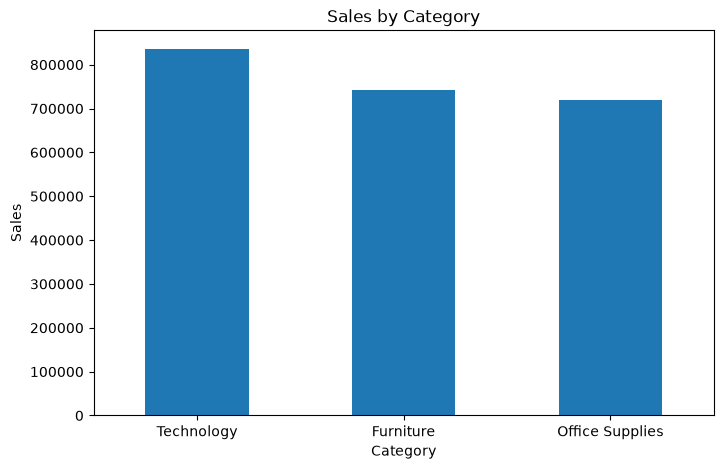

In [41]:
category_sales = (
    df.groupby("Category")["Sales"]
      .sum()
      .sort_values(ascending=False)
)

print(category_sales)

category_sales.plot(
    kind="bar",
    figsize=(8,5)
)

plt.title("Sales by Category")
plt.xlabel("Category")
plt.ylabel("Sales")
plt.xticks(rotation=0)

plt.show()

# Profit by Category

Analyze the profit generated by each product category to understand profitability beyond revenue.

## Business Insight

- High sales do not always result in high profit.
- Categories with strong profitability should receive greater business focus.

Category
Technology         145454.9481
Office Supplies    122490.8008
Furniture           18451.2728
Name: Profit, dtype: float64


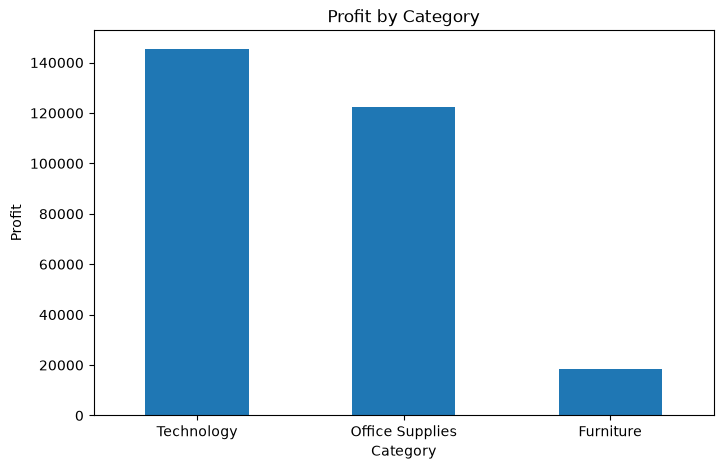

In [42]:
category_profit = (
    df.groupby("Category")["Profit"]
      .sum()
      .sort_values(ascending=False)
)

print(category_profit)

category_profit.plot(
    kind="bar",
    figsize=(8,5)
)

plt.title("Profit by Category")
plt.xlabel("Category")
plt.ylabel("Profit")
plt.xticks(rotation=0)

plt.show()

# Sales by Region

Compare sales performance across different geographical regions.

## Business Insight

- Identify the highest-performing region.
- Identify regions with growth potential.
- Regional performance can guide expansion strategies.

Region
West       725457.8245
East       678781.2400
Central    501239.8908
South      391721.9050
Name: Sales, dtype: float64


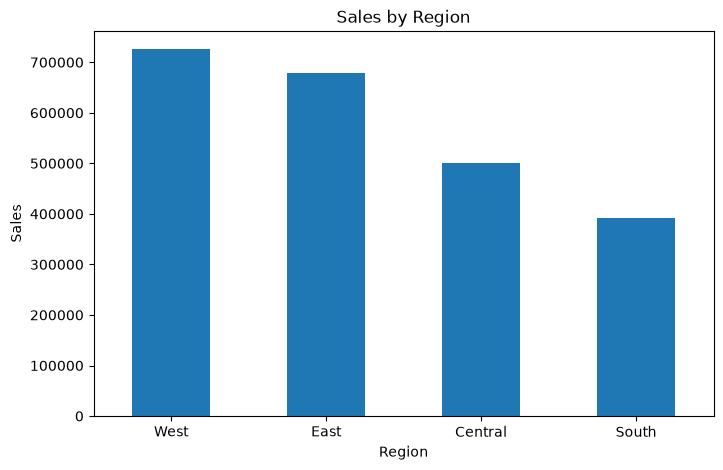

In [43]:
region_sales = (
    df.groupby("Region")["Sales"]
      .sum()
      .sort_values(ascending=False)
)

print(region_sales)

region_sales.plot(
    kind="bar",
    figsize=(8,5)
)

plt.title("Sales by Region")
plt.xlabel("Region")
plt.ylabel("Sales")
plt.xticks(rotation=0)

plt.show()

# Profit by Region

Evaluate regional profitability to determine where the company earns the highest returns.

## Business Insight

- Compare regional sales with regional profit.
- Focus on improving profitability in underperforming regions.

Region
West       108418.4489
East        91522.7800
South       46749.4303
Central     39706.3625
Name: Profit, dtype: float64


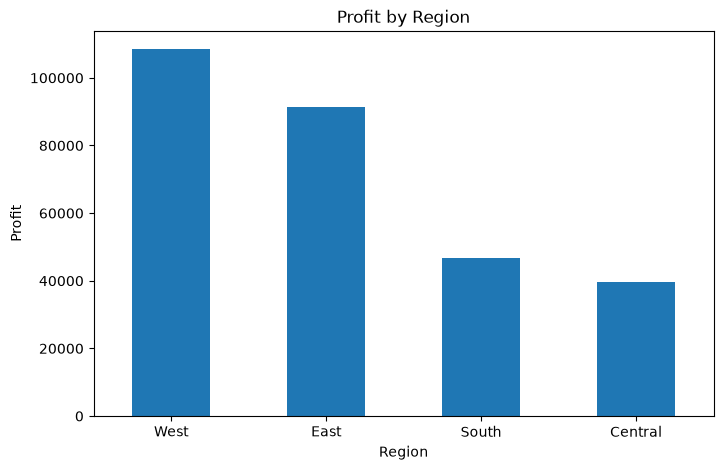

In [44]:
region_profit = (
    df.groupby("Region")["Profit"]
      .sum()
      .sort_values(ascending=False)
)

print(region_profit)

region_profit.plot(
    kind="bar",
    figsize=(8,5)
)

plt.title("Profit by Region")
plt.xlabel("Region")
plt.ylabel("Profit")
plt.xticks(rotation=0)

plt.show()

# Top 10 States by Sales

Identify the states contributing the highest sales revenue.


## Business Insight

- Top-performing states contribute a significant portion of total revenue.
- These markets should receive continued investment.

State
California      457687.6315
New York        310876.2710
Texas           170188.0458
Washington      138641.2700
Pennsylvania    116511.9140
Florida          89473.7080
Illinois         80166.1010
Ohio             78258.1360
Michigan         76269.6140
Virginia         70636.7200
Name: Sales, dtype: float64


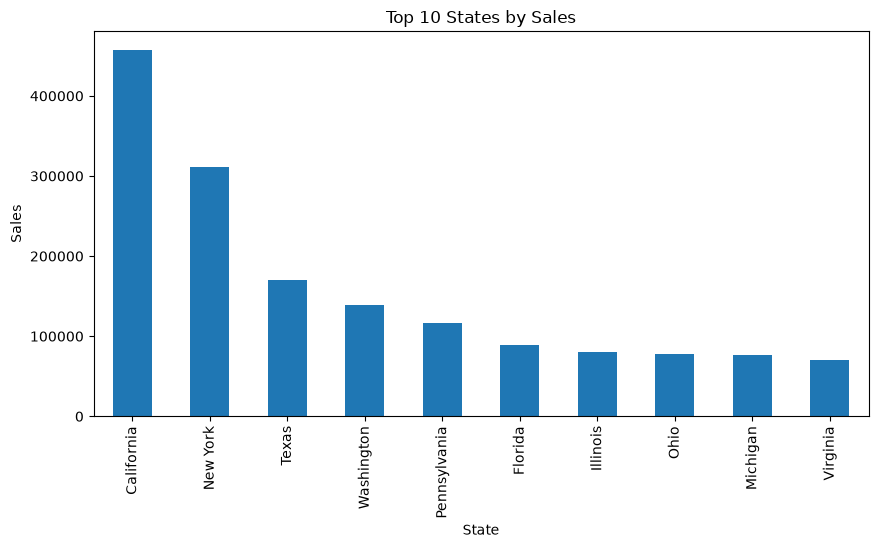

In [45]:
top_states = (
    df.groupby("State")["Sales"]
      .sum()
      .sort_values(ascending=False)
      .head(10)
)

print(top_states)

top_states.plot(
    kind="bar",
    figsize=(10,5)
)

plt.title("Top 10 States by Sales")
plt.xlabel("State")
plt.ylabel("Sales")

plt.show()

# Top 10 Cities by Sales

Identify cities with the strongest sales performance.

## Business Insight

- Cities with high sales can be targeted for promotional campaigns.
- Expanding operations in these cities may increase revenue.

City
New York City    256368.1610
Los Angeles      175851.3410
Seattle          119540.7420
San Francisco    112669.0920
Philadelphia     109077.0130
Houston           64504.7604
Chicago           48539.5410
San Diego         47521.0290
Jacksonville      44713.1830
Springfield       43054.3420
Name: Sales, dtype: float64


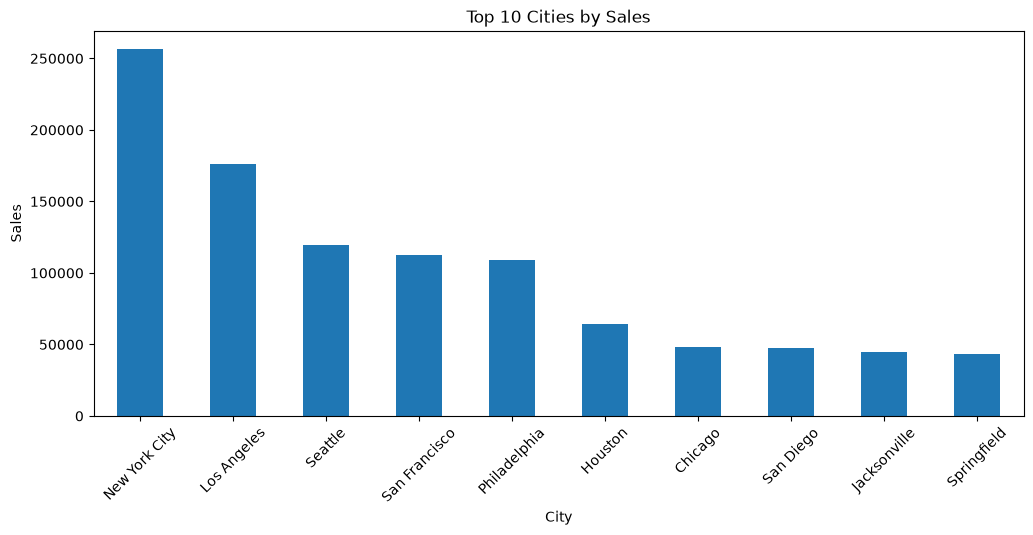

In [46]:
top_cities = (
    df.groupby("City")["Sales"]
      .sum()
      .sort_values(ascending=False)
      .head(10)
)

print(top_cities)

top_cities.plot(
    kind="bar",
    figsize=(12,5)
)

plt.title("Top 10 Cities by Sales")
plt.xlabel("City")
plt.ylabel("Sales")

plt.xticks(rotation=45)

plt.show()

# Sales by Customer Segment

Analyze how different customer segments contribute to overall sales.

## Business Insight

- Determine the largest revenue-generating customer segment.
- Marketing campaigns can be customized for each customer segment.

Segment
Consumer       1.161401e+06
Corporate      7.061464e+05
Home Office    4.296531e+05
Name: Sales, dtype: float64


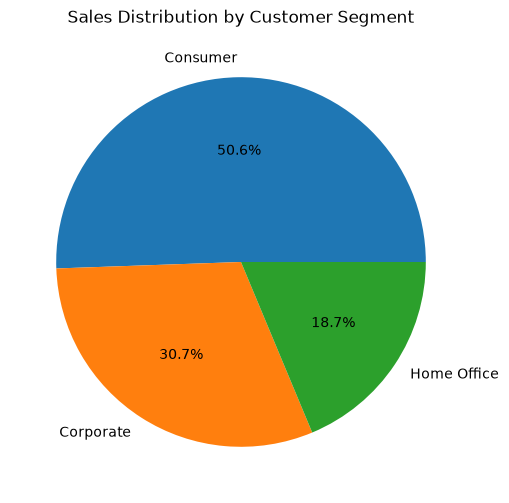

In [47]:
segment_sales = (
    df.groupby("Segment")["Sales"]
      .sum()
      .sort_values(ascending=False)
)

print(segment_sales)

segment_sales.plot(
    kind="pie",
    autopct="%1.1f%%",
    figsize=(6,6)
)

plt.ylabel("")
plt.title("Sales Distribution by Customer Segment")

plt.show()

# Monthly Sales Trend

Analyze monthly sales performance to identify seasonal trends.

## Business Insight

- Identify peak sales months.
- Seasonal demand can assist inventory and marketing planning.

Order Month Name
January       94924.8356
February      59751.2514
March        205005.4888
April        137762.1286
May          155028.8117
June         152718.6793
July         147238.0970
August       159044.0630
September    307649.9457
October      200322.9847
November     352461.0710
December     325293.5035
Name: Sales, dtype: float64


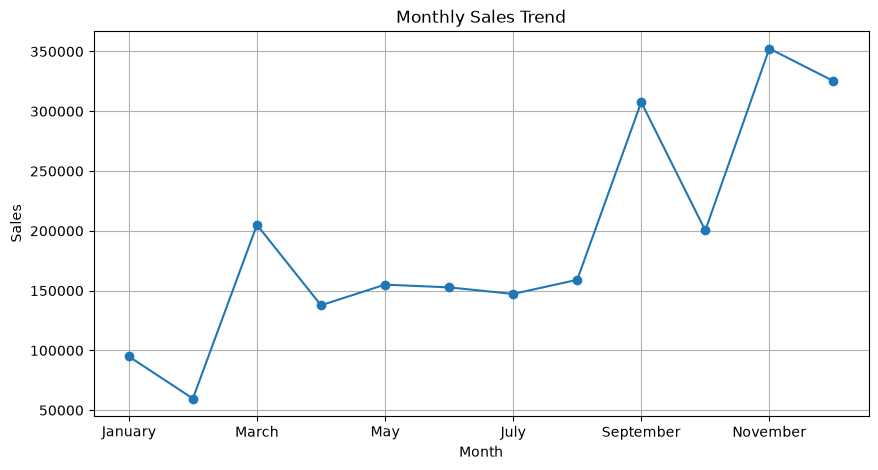

In [48]:
monthly_sales = (
    df.groupby("Order Month Name")["Sales"]
      .sum()
)

months = [
    "January","February","March","April","May","June",
    "July","August","September","October","November","December"
]

monthly_sales = monthly_sales.reindex(months)

print(monthly_sales)

monthly_sales.plot(
    marker="o",
    figsize=(10,5)
)

plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Sales")

plt.grid(True)

plt.show()

# Yearly Sales Trend

Compare annual sales performance to understand long-term business growth.

## Business Insight

- Evaluate whether sales increase consistently over the years.
- Long-term trends help forecast future business performance.

Order Year
2014    484247.4981
2015    470532.5090
2016    609205.5980
2017    733215.2552
Name: Sales, dtype: float64


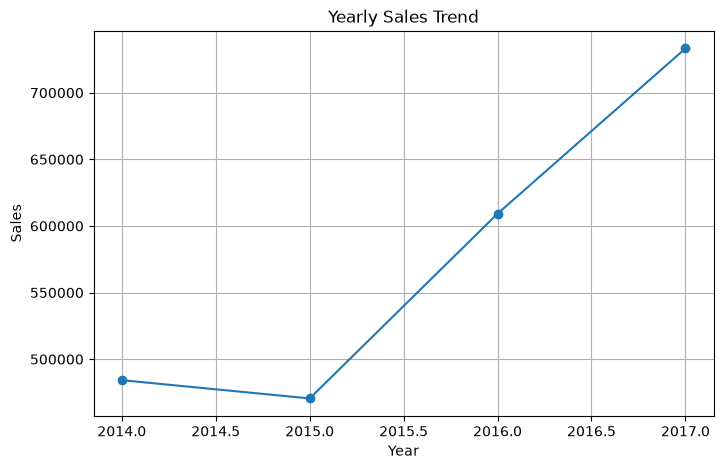

In [49]:
yearly_sales = (
    df.groupby("Order Year")["Sales"]
      .sum()
)

print(yearly_sales)

yearly_sales.plot(
    marker="o",
    figsize=(8,5)
)

plt.title("Yearly Sales Trend")
plt.xlabel("Year")
plt.ylabel("Sales")

plt.grid(True)

plt.show()

# Top 10 Products by Sales

Identify products generating the highest revenue.

## Business Insight

- High-selling products should remain consistently available.
- These products can be bundled with related products to increase sales.

Product Name
Canon imageCLASS 2200 Advanced Copier                                          61599.824
Fellowes PB500 Electric Punch Plastic Comb Binding Machine with Manual Bind    27453.384
Cisco TelePresence System EX90 Videoconferencing Unit                          22638.480
HON 5400 Series Task Chairs for Big and Tall                                   21870.576
GBC DocuBind TL300 Electric Binding System                                     19823.479
GBC Ibimaster 500 Manual ProClick Binding System                               19024.500
Hewlett Packard LaserJet 3310 Copier                                           18839.686
HP Designjet T520 Inkjet Large Format Printer - 24" Color                      18374.895
GBC DocuBind P400 Electric Binding System                                      17965.068
High Speed Automatic Electric Letter Opener                                    17030.312
Name: Sales, dtype: float64


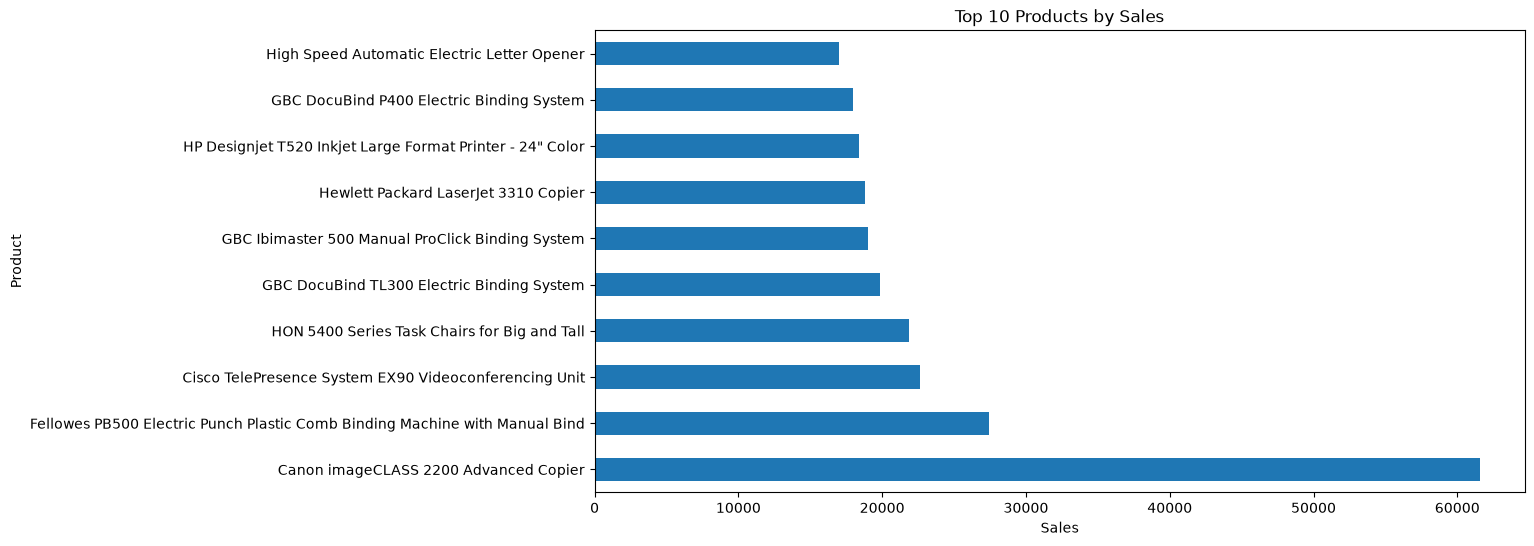

In [50]:
top_products_sales = (
    df.groupby("Product Name")["Sales"]
      .sum()
      .sort_values(ascending=False)
      .head(10)
)

print(top_products_sales)

top_products_sales.plot(
    kind="barh",
    figsize=(12,6)
)

plt.title("Top 10 Products by Sales")
plt.xlabel("Sales")
plt.ylabel("Product")

plt.show()

# Top 10 Products by Profit

Analyze products generating the highest profits.

## Business Insight

- High-profit products contribute significantly to business success.
- Marketing efforts should prioritize these products.

Product Name
Canon imageCLASS 2200 Advanced Copier                                          25199.9280
Fellowes PB500 Electric Punch Plastic Comb Binding Machine with Manual Bind     7753.0390
Hewlett Packard LaserJet 3310 Copier                                            6983.8836
Canon PC1060 Personal Laser Copier                                              4570.9347
HP Designjet T520 Inkjet Large Format Printer - 24" Color                       4094.9766
Ativa V4110MDD Micro-Cut Shredder                                               3772.9461
3D Systems Cube Printer, 2nd Generation, Magenta                                3717.9714
Plantronics Savi W720 Multi-Device Wireless Headset System                      3696.2820
Ibico EPK-21 Electric Binding System                                            3345.2823
Zebra ZM400 Thermal Label Printer                                               3343.5360
Name: Profit, dtype: float64


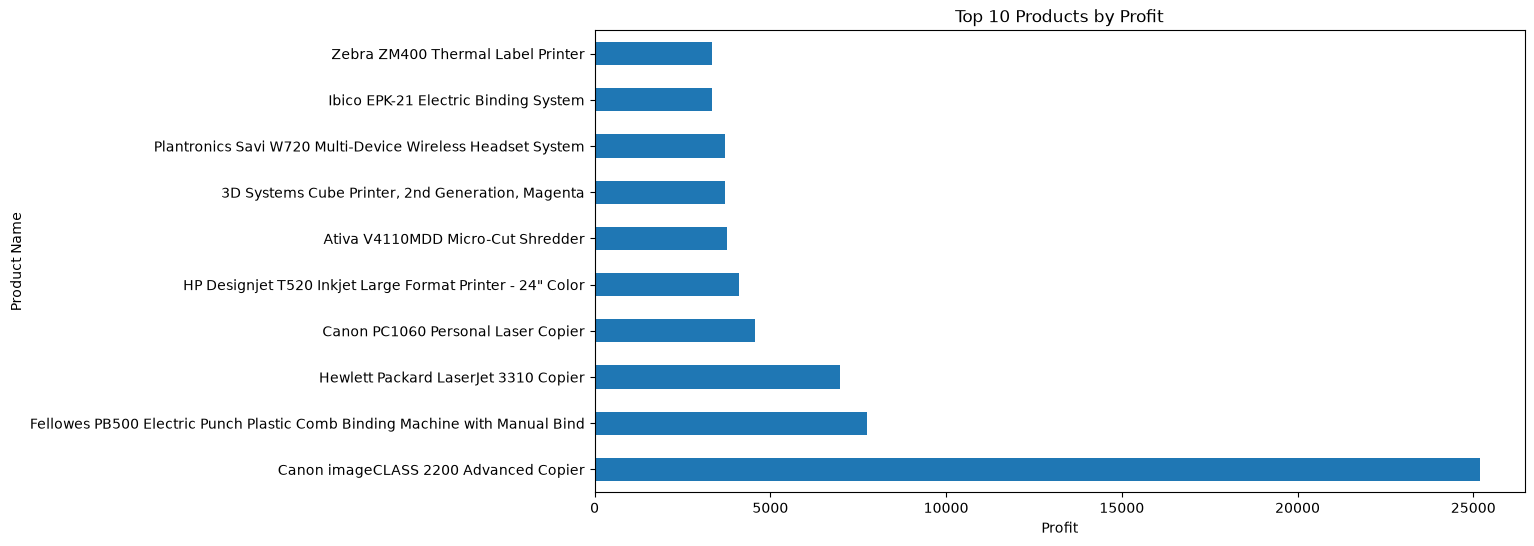

In [51]:
top_products_profit = (
    df.groupby("Product Name")["Profit"]
      .sum()
      .sort_values(ascending=False)
      .head(10)
)

print(top_products_profit)

top_products_profit.plot(
    kind="barh",
    figsize=(12,6)
)

plt.title("Top 10 Products by Profit")
plt.xlabel("Profit")

plt.show()

# Bottom 10 Products by Profit

Identify products generating the lowest or negative profits.

## Business Insight

- Loss-making products require pricing or discount review.
- Inventory decisions should consider product profitability.

Product Name
Cubify CubeX 3D Printer Double Head Print                           -8879.9704
Lexmark MX611dhe Monochrome Laser Printer                           -4589.9730
Cubify CubeX 3D Printer Triple Head Print                           -3839.9904
Chromcraft Bull-Nose Wood Oval Conference Tables & Bases            -2876.1156
Bush Advantage Collection Racetrack Conference Table                -1934.3976
GBC DocuBind P400 Electric Binding System                           -1878.1662
Cisco TelePresence System EX90 Videoconferencing Unit               -1811.0784
Martin Yale Chadless Opener Electric Letter Opener                  -1299.1836
Balt Solid Wood Round Tables                                        -1201.0581
BoxOffice By Design Rectangular and Half-Moon Meeting Room Tables   -1148.4375
Name: Profit, dtype: float64


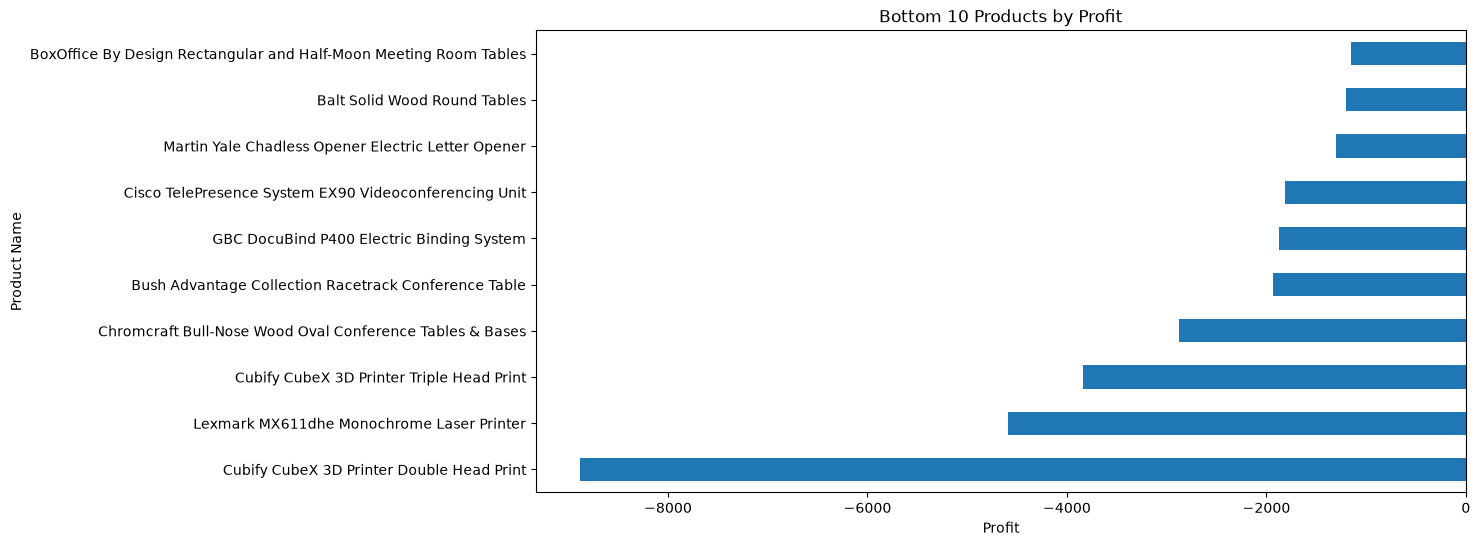

In [52]:
bottom_products = (
    df.groupby("Product Name")["Profit"]
      .sum()
      .sort_values()
      .head(10)
)

print(bottom_products)

bottom_products.plot(
    kind="barh",
    figsize=(12,6)
)

plt.title("Bottom 10 Products by Profit")
plt.xlabel("Profit")

plt.show()

# Top 10 Customers by Sales

Identify customers contributing the highest revenue.

## Business Insight

- High-value customers should be retained through loyalty programs.
- Personalized offers can improve customer retention.

Customer Name
Sean Miller           25043.050
Tamara Chand          19052.218
Raymond Buch          15117.339
Tom Ashbrook          14595.620
Adrian Barton         14473.571
Ken Lonsdale          14175.229
Sanjit Chand          14142.334
Hunter Lopez          12873.298
Sanjit Engle          12209.438
Christopher Conant    12129.072
Name: Sales, dtype: float64


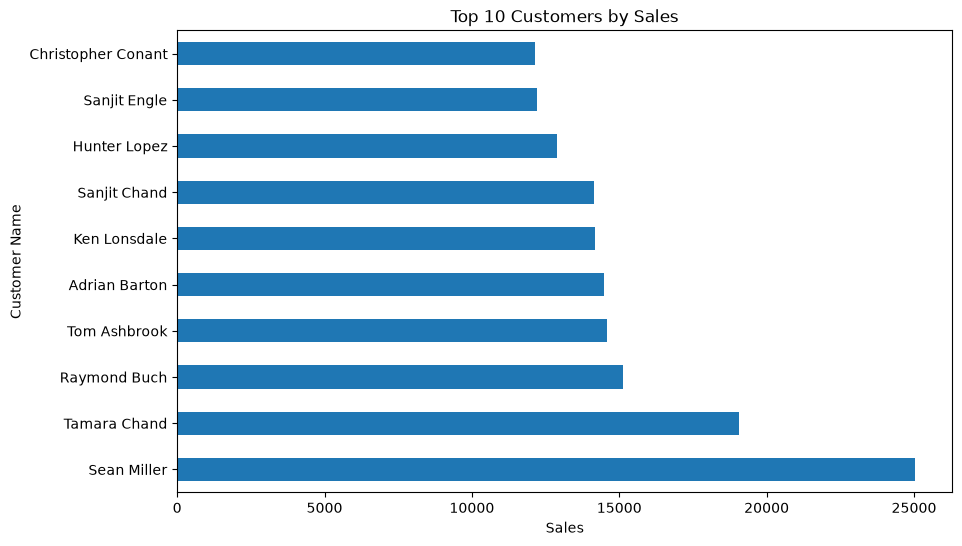

In [53]:
top_customers = (
    df.groupby("Customer Name")["Sales"]
      .sum()
      .sort_values(ascending=False)
      .head(10)
)

print(top_customers)

top_customers.plot(
    kind="barh",
    figsize=(10,6)
)

plt.title("Top 10 Customers by Sales")
plt.xlabel("Sales")

plt.show()

# Top 10 Customers by Profit

Analyze customers generating the highest profits.

## Business Insight

- Profitable customers are valuable long-term business assets.
- Customer relationship management strategies should focus on these customers.

Customer Name
Tamara Chand            8981.3239
Raymond Buch            6976.0959
Sanjit Chand            5757.4119
Hunter Lopez            5622.4292
Adrian Barton           5444.8055
Tom Ashbrook            4703.7883
Christopher Martinez    3899.8904
Keith Dawkins           3038.6254
Andy Reiter             2884.6208
Daniel Raglin           2869.0760
Name: Profit, dtype: float64


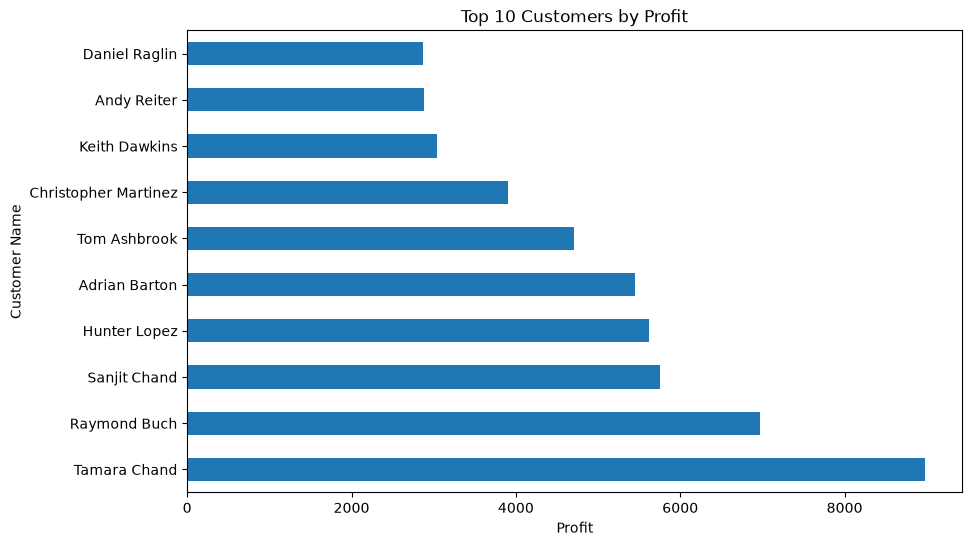

In [54]:
top_customer_profit = (
    df.groupby("Customer Name")["Profit"]
      .sum()
      .sort_values(ascending=False)
      .head(10)
)

print(top_customer_profit)

top_customer_profit.plot(
    kind="barh",
    figsize=(10,6)
)

plt.title("Top 10 Customers by Profit")
plt.xlabel("Profit")

plt.show()

# Discount vs Profit Analysis

Examine the relationship between discounts and profitability.

## Business Insight

- Higher discounts often reduce profit margins.
- Discount strategies should balance customer attraction and profitability.

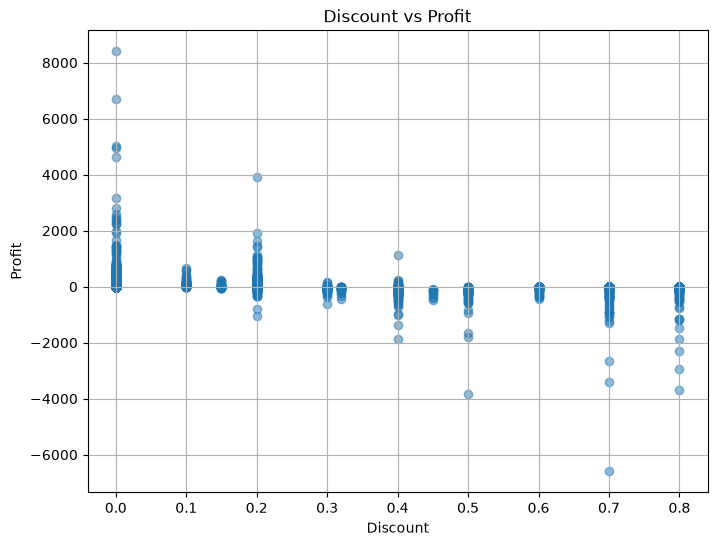

In [55]:
plt.figure(figsize=(8,6))

plt.scatter(
    df["Discount"],
    df["Profit"],
    alpha=0.5
)

plt.title("Discount vs Profit")
plt.xlabel("Discount")
plt.ylabel("Profit")

plt.grid(True)

plt.show()

# Correlation Analysis

Study relationships among important numerical variables, including Sales, Profit, Quantity, and Discount.

## Business Insight

- Correlation analysis identifies relationships between business variables.
- Strong relationships help guide future predictive modeling.

In [56]:
correlation = df[["Sales", "Profit", "Quantity", "Discount"]].corr()

print(correlation)

             Sales    Profit  Quantity  Discount
Sales     1.000000  0.479064  0.200795 -0.028190
Profit    0.479064  1.000000  0.066253 -0.219487
Quantity  0.200795  0.066253  1.000000  0.008623
Discount -0.028190 -0.219487  0.008623  1.000000


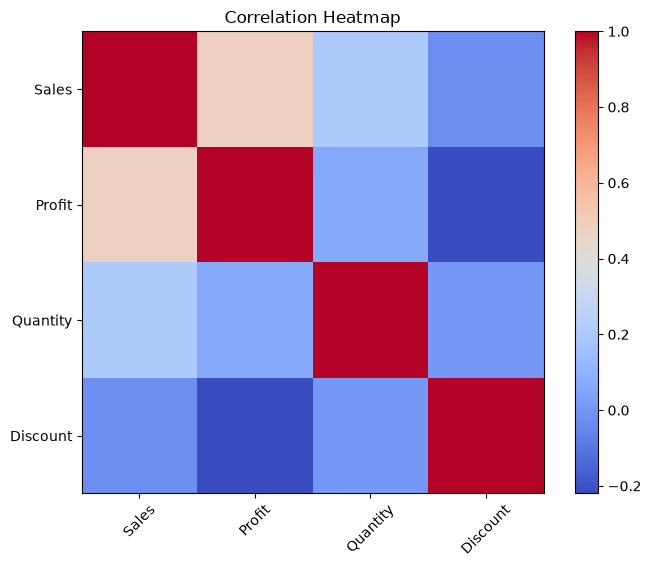

In [57]:
plt.figure(figsize=(8,6))

plt.imshow(correlation, cmap="coolwarm")

plt.colorbar()

plt.xticks(range(len(correlation.columns)), correlation.columns, rotation=45)
plt.yticks(range(len(correlation.columns)), correlation.columns)

plt.title("Correlation Heatmap")

plt.show()

# Summary

## Key Findings

- Technology generated the highest sales revenue.
- Consumer customers contributed the largest share of sales.
- The West region performed strongly in both sales and profit.
- Several products generated losses despite good sales.
- Higher discounts were generally associated with lower profits.
- Sales showed seasonal variations across months.

## Business Recommendations

- Focus marketing efforts on profitable categories and products.
- Improve performance in low-performing regions.
- Review discount strategies to improve profitability.
- Retain high-value customers through loyalty programs.
- Optimize inventory based on sales trends and seasonal demand.